# Class Exercise
- Text processing
- NLTK

In [4]:
import pandas as pd
import numpy as np
import re
import requests

from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

from nltk import PorterStemmer
import nltk

import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:

def remove_pattern(text,pattern):
    
    # re.findall() finds the pattern i.e @user and puts it in a list for further task
    r = re.findall(pattern,text)
    
    # re.sub() removes @user from the sentences in the dataset
    for i in r:
        text = re.sub(i,"",text)
    
    return text

In [6]:
import pandas as pd
raw_tweets = pd.read_csv('data/MichelleObama_tweets.csv')
raw_tweets.head()

,id,created_at,text,likes,in reply to,retweeted
0,1457850609017688070,2021-11-08 23:20:45+00:00,Happy #CelebrateFirstGen Day! I’m so proud of ...,9221,NaN,False
1,1456361035586211849,2021-11-04 20:41:43+00:00,You absolutely nailed it – she looks just like...,16752,NaN,False
2,1456358269597925380,2021-11-04 20:30:43+00:00,I love this! This is exactly why we created Ad...,3971,NaN,False
3,1455660478856929280,2021-11-02 22:17:57+00:00,RT @WhenWeAllVote: Haven’t voted yet? There's ...,0,NaN,False
4,1455502831918764034,2021-11-02 11:51:31+00:00,Vote in-person or drop off your ballot by the ...,2241,MichelleObama,False


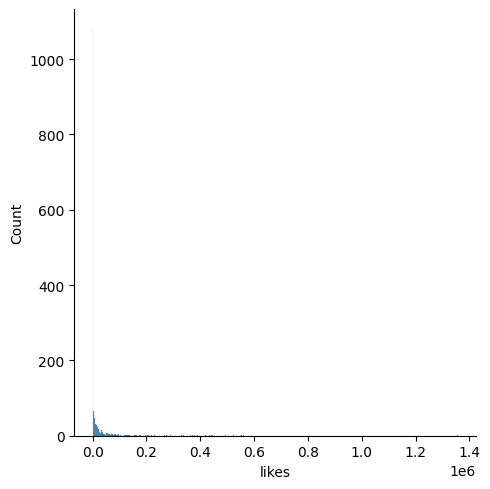

In [7]:

sns.displot(raw_tweets, x="likes")
plt.show()

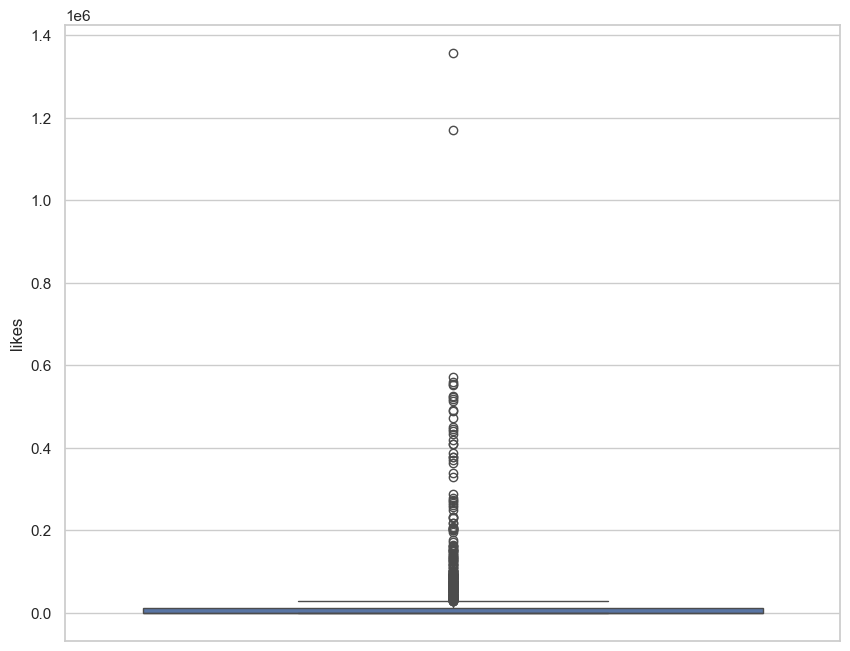

In [8]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,8))
ax = sns.boxplot(y='likes', data=raw_tweets, orient="v")
plt.show()

In [9]:
raw_tweets.describe()

,id,likes
count,1.806000e+03,1.806000e+03
mean,7.941456e+17,2.153503e+04
std,4.999847e+17,7.517971e+04
min,1.574469e+17,0.000000e+00
25%,2.431868e+17,1.825000e+01
50%,1.040864e+18,1.585000e+02
75%,1.276925e+18,1.154550e+04
max,1.457851e+18,1.357166e+06


In [10]:

raw_tweets['tidy_tweets'] = np.vectorize(remove_pattern)(raw_tweets['text'], "@[\w]*")
raw_tweets.head()

,id,created_at,text,likes,in reply to,retweeted,tidy_tweets
0,1457850609017688070,2021-11-08 23:20:45+00:00,Happy #CelebrateFirstGen Day! I’m so proud of ...,9221,NaN,False,Happy #CelebrateFirstGen Day! I’m so proud of ...
1,1456361035586211849,2021-11-04 20:41:43+00:00,You absolutely nailed it – she looks just like...,16752,NaN,False,You absolutely nailed it – she looks just like...
2,1456358269597925380,2021-11-04 20:30:43+00:00,I love this! This is exactly why we created Ad...,3971,NaN,False,I love this! This is exactly why we created Ad...
3,1455660478856929280,2021-11-02 22:17:57+00:00,RT @WhenWeAllVote: Haven’t voted yet? There's ...,0,NaN,False,RT : Haven’t voted yet? There's still time! Fi...
4,1455502831918764034,2021-11-02 11:51:31+00:00,Vote in-person or drop off your ballot by the ...,2241,MichelleObama,False,Vote in-person or drop off your ballot by the ...


In [11]:
raw_tweets['tidy_tweets'] = raw_tweets['tidy_tweets'].str.replace("[^a-zA-Z#]", " ", regex=True)
raw_tweets.head(10)

,id,created_at,text,likes,in reply to,retweeted,tidy_tweets
0,1457850609017688070,2021-11-08 23:20:45+00:00,Happy #CelebrateFirstGen Day! I’m so proud of ...,9221,NaN,False,Happy #CelebrateFirstGen Day I m so proud of ...
1,1456361035586211849,2021-11-04 20:41:43+00:00,You absolutely nailed it – she looks just like...,16752,NaN,False,You absolutely nailed it she looks just like...
2,1456358269597925380,2021-11-04 20:30:43+00:00,I love this! This is exactly why we created Ad...,3971,NaN,False,I love this This is exactly why we created Ad...
3,1455660478856929280,2021-11-02 22:17:57+00:00,RT @WhenWeAllVote: Haven’t voted yet? There's ...,0,NaN,False,RT Haven t voted yet There s still time Fi...
4,1455502831918764034,2021-11-02 11:51:31+00:00,Vote in-person or drop off your ballot by the ...,2241,MichelleObama,False,Vote in person or drop off your ballot by the ...
5,1455502826747187205,2021-11-02 11:51:30+00:00,Today is Election Day! From city hall and the ...,18911,NaN,False,Today is Election Day From city hall and the ...
6,1454827302353842178,2021-10-31 15:07:12+00:00,Barack and I always loved celebrating Hallowee...,52605,NaN,False,Barack and I always loved celebrating Hallowee...
7,1453780063091052544,2021-10-28 17:45:51+00:00,I’ve long been a fan of @BlackishABC’s wit and...,9646,NaN,False,I ve long been a fan of s wit and all around ...
8,1452422258119430144,2021-10-24 23:50:25+00:00,I’m so encouraged that the @POTUS and @VP have...,12557,NaN,False,I m so encouraged that the and have issued t...
9,1451556651488657409,2021-10-22 14:30:48+00:00,So this can’t be the end of our fight. We’re g...,1889,MichelleObama,False,So this can t be the end of our fight We re g...


In [12]:
raw_tweets['tidy_tweets'] = raw_tweets['tidy_tweets'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
raw_tweets.head(10)

,id,created_at,text,likes,in reply to,retweeted,tidy_tweets
0,1457850609017688070,2021-11-08 23:20:45+00:00,Happy #CelebrateFirstGen Day! I’m so proud of ...,9221,NaN,False,Happy #CelebrateFirstGen proud students workin...
1,1456361035586211849,2021-11-04 20:41:43+00:00,You absolutely nailed it – she looks just like...,16752,NaN,False,absolutely nailed looks just like Twist https ...
2,1456358269597925380,2021-11-04 20:30:43+00:00,I love this! This is exactly why we created Ad...,3971,NaN,False,love this This exactly created Twist Scientist...
3,1455660478856929280,2021-11-02 22:17:57+00:00,RT @WhenWeAllVote: Haven’t voted yet? There's ...,0,NaN,False,Haven voted There still time Find your polling...
4,1455502831918764034,2021-11-02 11:51:31+00:00,Vote in-person or drop off your ballot by the ...,2241,MichelleObama,False,Vote person drop your ballot time polls close ...
5,1455502826747187205,2021-11-02 11:51:30+00:00,Today is Election Day! From city hall and the ...,18911,NaN,False,Today Election From city hall governor mansion...
6,1454827302353842178,2021-10-31 15:07:12+00:00,Barack and I always loved celebrating Hallowee...,52605,NaN,False,Barack always loved celebrating Halloween back...
7,1453780063091052544,2021-10-28 17:45:51+00:00,I’ve long been a fan of @BlackishABC’s wit and...,9646,NaN,False,long been around brilliance such thrill join h...
8,1452422258119430144,2021-10-24 23:50:25+00:00,I’m so encouraged that the @POTUS and @VP have...,12557,NaN,False,encouraged that have issued first ever nationa...
9,1451556651488657409,2021-10-22 14:30:48+00:00,So this can’t be the end of our fight. We’re g...,1889,MichelleObama,False,this fight going keep working protect access b...


In [13]:
tokenized_tweet = raw_tweets['tidy_tweets'].apply(lambda x: x.split())
tokenized_tweet

0       [Happy, #CelebrateFirstGen, proud, students, w...
1       [absolutely, nailed, looks, just, like, Twist,...
2       [love, this, This, exactly, created, Twist, Sc...
3       [Haven, voted, There, still, time, Find, your,...
4       [Vote, person, drop, your, ballot, time, polls...
                              ...                        
1801    [Here, something, dear, heart, Service, Will, ...
1802    [Yesterday, First, Lady, announced, commitment...
1803    [everyone, thanks, warm, welcome, Look, forwar...
1804    [This, account, will, managed, campaign, staff...
1805    [excited, today, launch, connect, with, First,...
Name: tidy_tweets, Length: 1806, dtype: object

In [14]:
ps = PorterStemmer()
tokenized_tweet = tokenized_tweet.apply(lambda x: [ps.stem(i) for i in x])
tokenized_tweet

0       [happi, #celebratefirstgen, proud, student, wo...
1       [absolut, nail, look, just, like, twist, http,...
2       [love, thi, thi, exactli, creat, twist, scient...
3       [haven, vote, there, still, time, find, your, ...
4       [vote, person, drop, your, ballot, time, poll,...
                              ...                        
1801    [here, someth, dear, heart, servic, will, join...
1802    [yesterday, first, ladi, announc, commit, that...
1803    [everyon, thank, warm, welcom, look, forward, ...
1804    [thi, account, will, manag, campaign, staff, w...
1805    [excit, today, launch, connect, with, first, l...
Name: tidy_tweets, Length: 1806, dtype: object

In [15]:
for i in range(len(tokenized_tweet)):
    tokenized_tweet[i] = ' '.join(tokenized_tweet[i])
raw_tweets['tidy_tweets'] = tokenized_tweet
raw_tweets.head()

,id,created_at,text,likes,in reply to,retweeted,tidy_tweets
0,1457850609017688070,2021-11-08 23:20:45+00:00,Happy #CelebrateFirstGen Day! I’m so proud of ...,9221,NaN,False,happi #celebratefirstgen proud student work th...
1,1456361035586211849,2021-11-04 20:41:43+00:00,You absolutely nailed it – she looks just like...,16752,NaN,False,absolut nail look just like twist http tzkf aatd
2,1456358269597925380,2021-11-04 20:30:43+00:00,I love this! This is exactly why we created Ad...,3971,NaN,False,love thi thi exactli creat twist scientist thr...
3,1455660478856929280,2021-11-02 22:17:57+00:00,RT @WhenWeAllVote: Haven’t voted yet? There's ...,0,NaN,False,haven vote there still time find your poll pla...
4,1455502831918764034,2021-11-02 11:51:31+00:00,Vote in-person or drop off your ballot by the ...,2241,MichelleObama,False,vote person drop your ballot time poll close h...


In [16]:
all_words_likes = ' '.join(text for text in raw_tweets['tidy_tweets'][raw_tweets['likes']>500000])

In [17]:
# combining the image with the dataset
Mask = np.array(Image.open(requests.get('http://clipart-library.com/image_gallery2/Twitter-PNG-Image.png', stream=True).raw))

# We use the ImageColorGenerator library from Wordcloud 
# Here we take the color of the image and impose it over our wordcloud
image_colors = ImageColorGenerator(Mask)

# Now we use the WordCloud function from the wordcloud library 
wc = WordCloud(background_color='black', height=1500, width=4000,mask=Mask).generate(all_words_likes)


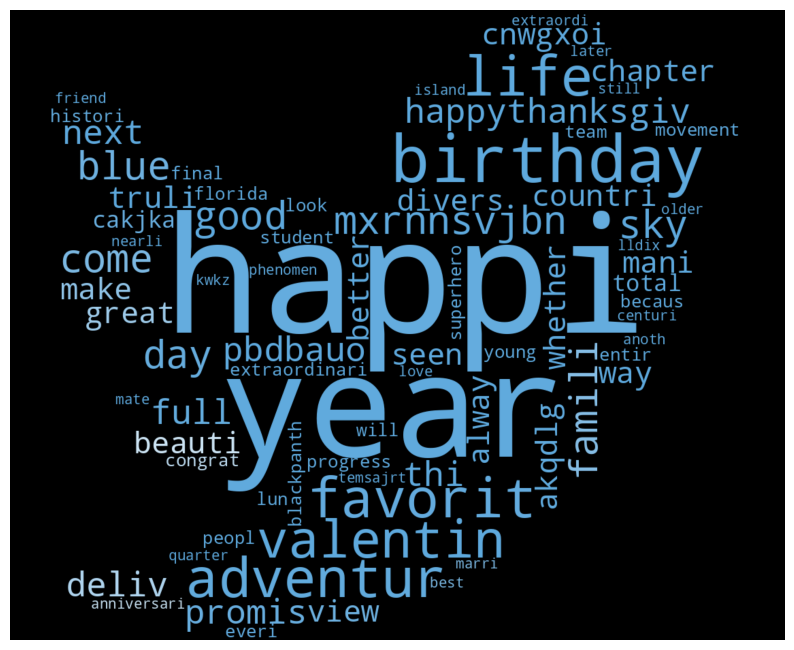

In [18]:
# Size of the image generated 
plt.figure(figsize=(10,20))

# Here we recolor the words from the dataset to the image's color
# recolor just recolors the default colors to the image's blue color
# interpolation is used to smooth the image generated 
plt.imshow(wc.recolor(color_func=image_colors),interpolation="hamming")

plt.axis('off')
plt.show()

In [19]:
def Hashtags_Extract(x):
    hashtags=[]
    
    # Loop over the words in the tweet
    for i in x:
        ht = re.findall(r'#(\w+)',i)
        hashtags.append(ht)
    
    return hashtags

In [20]:
ht_likes = Hashtags_Extract(raw_tweets['tidy_tweets'][raw_tweets['likes']>1000])
#ht_likes

In [21]:
ht_likes_unnest = sum(ht_likes,[])
#ht_likes_unnest

In [22]:
word_freq_likes = nltk.FreqDist(ht_likes_unnest)
word_freq_likes

FreqDist({'iambecom': 28, 'collegesigningday': 18, 'michelleobamapodcast': 10, 'reachhigh': 8, 'bettermakeroom': 7, 'electionday': 6, 'votingsquad': 6, 'dayofthegirl': 5, 'fathersday': 5, 'mothersday': 4, ...})

In [23]:
df_likes = pd.DataFrame({'Hashtags':list(word_freq_likes.keys()),'Count':list(word_freq_likes.values())})
df_likes.head(10)

,Hashtags,Count
0,celebratefirstgen,1
1,dayofthegirl,5
2,inspir,1
3,obamascholar,1
4,fathersday,5
5,juneteenth,3
6,deargrad,1
7,reachhigh,8
8,mothersday,4
9,collegesigningday,18


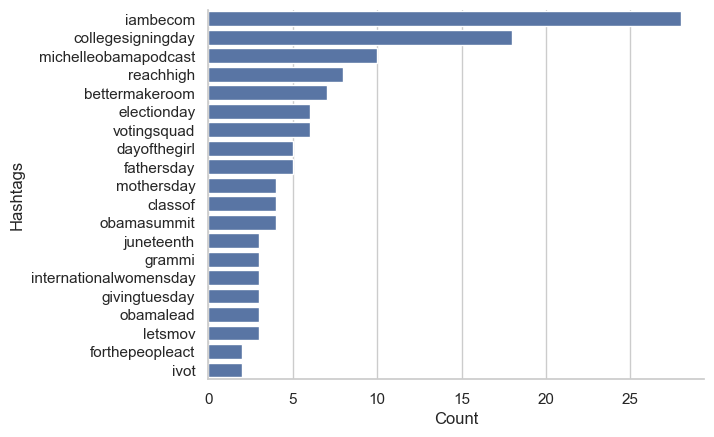

In [24]:
df_likes_plot = df_likes.nlargest(20,columns='Count')
sns.barplot(data=df_likes_plot,y='Hashtags',x='Count')
sns.despine()
plt.show()